# 03 - Time-based split with walk-forward validation

Splits the cleaned data **by time, never randomly**:

| Part | Share of rows | Used for |
|---|---|---|
| Development data | earliest 80% | cut into 5 time-ordered blocks for walk-forward validation: every choice is made here |
| Test group | latest 20% | the final, honest result, looked at **once**, at the very end |

**Walk-forward validation:** in each of 4 rounds, a model learns from all earlier blocks and is checked on the next block (round 1: learn B1, check B2; round 2: learn B1-B2, check B3; and so on). Every check is on later data, so no round ever peeks at the future. Choices are judged on the pooled check blocks, far more fraud cases than one fixed validation group could hold. (A first 60/20/20 split left validation with only 57 fraud cases; see DECISIONS.md.)

**A 10-minute gap:** transactions in the first 10 minutes after each boundary are not scored when checking or testing, so a burst of fraud can't be learned on one side of a boundary and "recognised" on the other.

In [1]:
import sys

import pandas as pd

print(sys.executable)

transactions = pd.read_csv("../data/processed/creditcard_clean.csv")
print(transactions.shape)

C:\Users\RevathyHarichandran\Desktop\portfolio projects\Fraud_detection\.venv\Scripts\python.exe


(283726, 32)


## Step 1: Sort by Time

Notebook 01 showed the file is already in time order, but sorting explicitly keeps the split correct even if the file were ever saved in a different order. Within the same second, rows are ordered by `row_id`, so the order is identical on every run. `reset_index(drop=True)` renumbers the rows 0, 1, 2, ... in the new order (explained in notebook 01, Step 9), so a row's number is its position.

In [2]:
transactions = transactions.sort_values(["Time", "row_id"])
transactions = transactions.reset_index(drop=True)

print(transactions["Time"].is_monotonic_increasing)

True


## Step 2: Lock away the latest 20% as the test group

**The tie rule** decided in Phase 1: transactions from the **same second always go into the same part**, so a cut is only ever made **between two different seconds**:

1. `target_rows` is where the cut would fall exactly (80% of the rows, rounded down to a whole row by `int()`).
2. `second_at_target` is the second of the row sitting there.
3. The development data can end just **before** that second (`rows_before` rows) or just **after** it (`rows_through` rows). The `if` picks whichever is closer to `target_rows`; it can be off by at most 36 rows, the largest number of transactions in any one second.
4. The result is recorded as the **last second** of the development data. Rows are sorted, so the rows before `second_at_target` are positions 0 to `rows_before - 1`.

The two parts are then made by boolean filtering on Time (notebook 01, Step 4), and each is renumbered from 0.

In [3]:
total_rows = len(transactions)

target_rows = int(total_rows * 0.80)
second_at_target = transactions["Time"][target_rows]
rows_before = (transactions["Time"] < second_at_target).sum()
rows_through = (transactions["Time"] <= second_at_target).sum()

if target_rows - rows_before <= rows_through - target_rows:
    development_last_second = transactions["Time"][rows_before - 1]
else:
    development_last_second = second_at_target

print("target row:", target_rows, "| second there:", second_at_target)
print("ending before it gives", rows_before, "rows; ending after it gives", rows_through, "rows")
print("last second of development data:", development_last_second)

development = transactions[transactions["Time"] <= development_last_second].reset_index(drop=True)
test = transactions[transactions["Time"] > development_last_second].reset_index(drop=True)

print("development rows:", len(development), "| test rows:", len(test))

target row: 226980 | second there: 145234.0
ending before it gives 226980 rows; ending after it gives 226982 rows
last second of development data: 145233.0
development rows: 226980 | test rows: 56746


## Step 3: Cut the development data into 5 time-ordered blocks

The same tie rule at each of the 20%, 40%, 60% and 80% marks of the development data. Instead of copying the cut code four times, a `for` loop (first explained in notebook 01, Step 6) runs it once per mark and collects each block's last second in a list. The last block simply ends where the development data ends.

In [4]:
number_of_blocks = 5
block_last_seconds = []

for block_number in range(1, number_of_blocks):
    target_rows = int(len(development) * block_number / number_of_blocks)
    second_at_target = development["Time"][target_rows]
    rows_before = (development["Time"] < second_at_target).sum()
    rows_through = (development["Time"] <= second_at_target).sum()
    if target_rows - rows_before <= rows_through - target_rows:
        block_last_seconds.append(development["Time"][rows_before - 1])
    else:
        block_last_seconds.append(second_at_target)

block_last_seconds.append(development["Time"].max())
print("last second of each block:", block_last_seconds)

last second of each block: [np.float64(42413.0), np.float64(63318.0), np.float64(81825.0), np.float64(125321.0), np.float64(145233.0)]


Now label every development row with its block number, in a new `block` column. For each block, a row belongs to it if its Time is after the previous block's last second and up to this block's last second. `development.loc[rows, "block"] = value` sets the `block` column to `value` for just the rows marked `True` (`.loc` picks rows and a column by label). `lower` starts at -1 so the very first transaction, at second 0, is included in block 1.

In [5]:
development["block"] = 0
lower = -1

for position in range(number_of_blocks):
    upper = block_last_seconds[position]
    in_this_block = (development["Time"] > lower) & (development["Time"] <= upper)
    development.loc[in_this_block, "block"] = position + 1
    lower = upper

print(development["block"].value_counts().sort_index())

block
1    45397
2    45395
3    45394
4    45398
5    45396
Name: count, dtype: int64


## Step 4: Mark the 10-minute gaps

A new `in_gap` column is `True` for any transaction in the first 600 seconds (10 minutes) after a boundary: the starts of blocks 2 to 5, and the start of the test group. Nothing is removed. Later notebooks skip `in_gap` rows only when **scoring** a check block or the test group; the rows are still used for learning in later rounds, where they lie in the past.

**Why 10 minutes:** a check of fraud near each boundary found a burst of exactly-1.00 fraud transactions on both sides of the B1/B2 boundary. 10 minutes removes its closest continuations while costing only 7 of the 257 check fraud cases and no test fraud cases; 30 minutes would have cost 16 check and 5 test fraud cases (see DECISIONS.md). `gap_seconds` holds the rule in one place.

In [6]:
gap_seconds = 600

development["in_gap"] = False
for position in range(number_of_blocks - 1):
    boundary = block_last_seconds[position]
    just_after = (development["Time"] > boundary) & (development["Time"] <= boundary + gap_seconds)
    development.loc[just_after, "in_gap"] = True

test["in_gap"] = test["Time"] <= development_last_second + gap_seconds

print("development gap rows:", development["in_gap"].sum(), "| fraud among them:", development[development["in_gap"]]["Class"].sum())
print("test gap rows:", test["in_gap"].sum(), "| fraud among them:", test[test["in_gap"]]["Class"].sum())

development gap rows: 5408 | fraud among them: 7
test gap rows: 1374 | fraud among them: 0


## Step 5: Check the split is clean

- Development and test rows must add up to the total: no row lost or doubled.
- No `row_id` may appear in both (`isin()` marks each row whose `row_id` is found in the other part; the count must be 0).
- Every block must end **strictly before** the next one starts, and the development data strictly before the test group, which proves no second is shared across any boundary.

In [7]:
print("rows add up:", len(development) + len(test) == total_rows)
print("shared row_ids:", development["row_id"].isin(test["row_id"]).sum())

for block_number in range(1, number_of_blocks):
    this_block = development[development["block"] == block_number]
    next_block = development[development["block"] == block_number + 1]
    print(f"block {block_number} ends before block {block_number + 1} starts:", this_block["Time"].max() < next_block["Time"].min())

print("development ends before test starts:", development["Time"].max() < test["Time"].min())

rows add up: True
shared row_ids: 0
block 1 ends before block 2 starts: True
block 2 ends before block 3 starts: True
block 3 ends before block 4 starts: True
block 4 ends before block 5 starts: True
development ends before test starts: True


## Step 6: What each block and each round contains

Per block: rows, fraud count, fraud rate, and the stretch of time covered (hours since the first transaction). Per round: what it learns from, and the fraud it is checked on once the gap rows are left out.

In [8]:
for block_number in range(1, number_of_blocks + 1):
    block = development[development["block"] == block_number]
    print(f"B{block_number}: {len(block):6,} rows  fraud {block['Class'].sum():3}  ({block['Class'].mean() * 100:.3f}%)  hours {block['Time'].min() / 3600:5.2f} to {block['Time'].max() / 3600:5.2f}")

print()
total_check_fraud = 0
for round_number in range(1, number_of_blocks):
    learn = development[development["block"] <= round_number]
    check = development[(development["block"] == round_number + 1) & (~development["in_gap"])]
    total_check_fraud = total_check_fraud + check["Class"].sum()
    print(f"round {round_number}: learn B1-B{round_number} ({len(learn):7,} rows, {learn['Class'].sum()} fraud) -> check B{round_number + 1} ({len(check):,} rows after the gap, {check['Class'].sum()} fraud)")

print("fraud used for checking, pooled:", total_check_fraud)

B1: 45,397 rows  fraud 142  (0.313%)  hours  0.00 to 11.78


B2: 45,395 rows  fraud  69  (0.152%)  hours 11.78 to 17.59
B3: 45,394 rows  fraud  47  (0.104%)  hours 17.59 to 22.73
B4: 45,398 rows  fraud  89  (0.196%)  hours 22.73 to 34.81
B5: 45,396 rows  fraud  52  (0.115%)  hours 34.81 to 40.34

round 1: learn B1-B1 ( 45,397 rows, 142 fraud) -> check B2 (44,015 rows after the gap, 66 fraud)


round 2: learn B1-B2 ( 90,792 rows, 211 fraud) -> check B3 (44,111 rows after the gap, 46 fraud)


round 3: learn B1-B3 (136,186 rows, 258 fraud) -> check B4 (44,114 rows after the gap, 88 fraud)


round 4: learn B1-B4 (181,584 rows, 347 fraud) -> check B5 (43,935 rows after the gap, 50 fraud)


fraud used for checking, pooled: 250


## Step 7: The test group

**This is all that is ever looked at in the test group until the final evaluation in Phase 6:** its size, fraud count, fraud rate, time span and gap rows. No charts, no distributions, no model scores.

In [9]:
print(f"test: {len(test):,} rows ({len(test) / total_rows * 100:.2f}%)  fraud {test['Class'].sum()}  ({test['Class'].mean() * 100:.3f}%)  hours {test['Time'].min() / 3600:.2f} to {test['Time'].max() / 3600:.2f}")
print(f"scored test rows (after the gap): {(~test['in_gap']).sum():,}  fraud {test[~test['in_gap']]['Class'].sum()}")

test: 56,746 rows (20.00%)  fraud 74  (0.130%)  hours 40.34 to 48.00
scored test rows (after the gap): 55,372  fraud 74


## Step 8: Save the two parts

`development.csv` keeps the `block` and `in_gap` columns; `test.csv` keeps `in_gap`. `index=False` as in notebook 01, Step 2.

**The agreement: `test.csv` is not opened again until the final evaluation in Phase 6.** Every notebook from Phase 4 onwards loads only `development.csv`.

In [10]:
development.to_csv("../data/processed/development.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)

## Step 9: Does fraud look different over time? A chart

The fraud rate of each development block and of the test group, in time order. Using the test group here does not break the agreement: its fraud rate was already reported in Step 7, and nothing new about it is examined.

Each bar rests on only 47 to 142 fraud cases, so part of any difference could be luck. Each bar therefore gets a **95% bootstrap confidence interval**: the same resampling loop as notebook 02, Chart 5 (see there for the full explanation), with 1,000 resamples and seed 42. Here the number recalculated on each resample is the fraud rate: the mean of `Class` (1 for fraud), times 100.

In [11]:
import numpy as np

number_of_resamples = 1000
rng = np.random.default_rng(42)

# The six parts in time order: blocks 1 to 5, then the test group.
part_names = []
part_frames = []
for block_number in range(1, number_of_blocks + 1):
    part_names.append("B" + str(block_number))
    part_frames.append(development[development["block"] == block_number])
part_names.append("Test")
part_frames.append(test)

part_rates = []
part_lowers = []
part_uppers = []
part_fraud_counts = []
part_hour_labels = []

for position in range(len(part_frames)):
    frame = part_frames[position]
    class_values = frame["Class"].to_numpy()

    resampled_rates = []
    for resample_number in range(number_of_resamples):
        resample = rng.choice(class_values, size=len(class_values), replace=True)
        resampled_rates.append(resample.mean() * 100)

    part_rates.append(class_values.mean() * 100)
    part_lowers.append(np.percentile(resampled_rates, 2.5))
    part_uppers.append(np.percentile(resampled_rates, 97.5))
    part_fraud_counts.append(class_values.sum())
    part_hour_labels.append(f"hours {frame['Time'].min() / 3600:.1f}-{frame['Time'].max() / 3600:.1f}")

    print(f"{part_names[position]:5s} rate {part_rates[-1]:.3f}%  95% CI {part_lowers[-1]:.3f}% to {part_uppers[-1]:.3f}%  ({part_fraud_counts[-1]} fraud)")

B1    rate 0.313%  95% CI 0.260% to 0.364%  (142 fraud)


B2    rate 0.152%  95% CI 0.119% to 0.187%  (69 fraud)


B3    rate 0.104%  95% CI 0.077% to 0.134%  (47 fraud)


B4    rate 0.196%  95% CI 0.156% to 0.238%  (89 fraud)


B5    rate 0.115%  95% CI 0.086% to 0.148%  (52 fraud)


Test  rate 0.130%  95% CI 0.099% to 0.160%  (74 fraud)


In the cell above, `[-1]` means "the last item in the list", here the value just added for the current part.

The chart:
- Blue bars for the five development blocks; a grey bar for the test group, marking it as the locked-away part (orange is kept for "fraud" in this project's charts).
- **Error bars:** `yerr` draws a thin vertical line through each bar's top, from the lower to the upper end of its confidence interval. It needs two lists: how far the line reaches *below* each bar's height, and how far *above*. `capsize=4` adds short caps at the ends.
- Above each error bar, the rate and fraud count; under each bar, its name and the hours it covers (`\n` starts a new line in a label).
- A horizontal line at the overall fraud rate across all 283,726 transactions (473 fraud), for comparison.

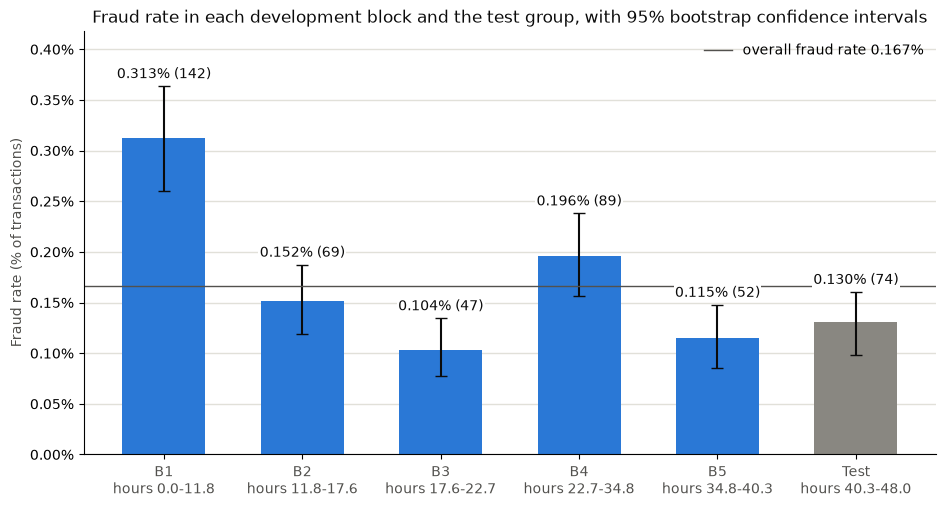

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

overall_rate = transactions["Class"].mean() * 100

below_bar = []
above_bar = []
tick_labels = []
for position in range(len(part_names)):
    below_bar.append(part_rates[position] - part_lowers[position])
    above_bar.append(part_uppers[position] - part_rates[position])
    tick_labels.append(part_names[position] + "\n" + part_hour_labels[position])

bar_colors = ["#2a78d6", "#2a78d6", "#2a78d6", "#2a78d6", "#2a78d6", "#898781"]

fig, ax = plt.subplots(figsize=(11, 5.5))
positions = range(len(part_names))
ax.bar(positions, part_rates, width=0.6, color=bar_colors,
       yerr=[below_bar, above_bar], capsize=4, ecolor="#0b0b0b")

# Each label gets a small white background (bbox) so a line behind it,
# like the overall-rate line, can't run through the text.
for position in positions:
    label = f"{part_rates[position]:.3f}% ({part_fraud_counts[position]})"
    ax.text(position, part_uppers[position] + 0.008, label, ha="center", color="#0b0b0b",
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})

ax.axhline(overall_rate, color="#52514e", linewidth=1, label=f"overall fraud rate {overall_rate:.3f}%")
ax.legend(frameon=False, loc="upper right")

ax.set_xticks(positions)
ax.set_xticklabels(tick_labels, color="#52514e")
ax.set_ylabel("Fraud rate (% of transactions)", color="#52514e")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.2f}%"))
# A little headroom above the tallest label, so it doesn't crowd the title.
ax.set_ylim(0, max(part_uppers) * 1.15)
ax.set_title("Fraud rate in each development block and the test group, with 95% bootstrap confidence intervals", color="#0b0b0b")

ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.savefig("../outputs/figures/07_fraud_rate_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

**What this shows:** the fraud rate genuinely changes over time, and not just by luck.
- **B1 stands clearly apart:** 0.313% (95% CI 0.260% to 0.364%). Its interval doesn't overlap any other part's, so its higher rate is very unlikely to be chance. B1 contains the first night-time period.
- **B4 is also clearly higher than B3 and B5:** 0.196% (0.156% to 0.238%) against B3's 0.077% to 0.134% and B5's 0.086% to 0.148%, with no overlap. B4 contains the second night-time period. This matches notebook 02: fraud's share rises when genuine spending drops at night.
- **B2, B3, B5 and the test group overlap each other,** so the differences among these daytime and evening stretches may just be noise.
- **In practice:** a model learning from the early blocks sees fraud at up to twice the rate it will meet later (a real case of prior probability shift). A random split would mix all of these together and hide this; the time-ordered split and walk-forward rounds keep it visible, and let us check later whether a method's performance holds up across these different stretches.